In [34]:

from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
from scipy import stats
import scipy


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

import seaborn as sns 

from sbin.SuppressionSimulator import SuppressionSimulator
from sbin.simulation_helper import run_trials
from sbin.plotting_utilities import plot_hist_confidence, plot_ecdf_confidence, ecdf_grid
from sbin.complexity import create_complexity_df

with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
          
# this will be the conjoined list of binaries
binaries = data["binaries_filtered"]
#binaries = binaries[(binaries['Teff1']>4000) & (binaries['Teff1']<6000)].copy()

# separation values (as lists) for each star in binary sample
tmp = binaries.groupby('KOI')['SepAU'].agg('unique')
binary_separations = np.concatenate(tmp.to_numpy())

# this will be the KOIs that are presumed single
singles = data["kois_filtered_cc"]
#singles = singles[ (singles['teff']>4000) & (singles['teff']<6000)]



In [45]:


# Power Analysis: Distinguishing Snowline vs Moe & Kratter Suppression

from sbin.suppression_utilities import suppression_factor_snow as snow_sup
from sbin.suppression_utilities import suppression_factor_mk21 as mk_sup

# Reload tess if needed
tess = Table.read('tables/TOI_2026.03.14_13.14.58.votable').to_pandas()


def power_analysis(sim_hot, sim_cool, 
                   sample_sizes, n_subsamples=10, n_trials_per_sub=10):

    power_logsep = []
    power_radii = []

    for n in sample_sizes:
        p_logsep_ks = []
        p_logsep_ad = []
        p_radii = []

        #plt.figure()

        for _ in range(n_subsamples):

            sim_hot.run(max_a_draw=300.)
            sim_cool.run(max_a_draw=300.)

            hot_result = sim_hot.get_results(suppression_style='planets')
            cool_result = sim_cool.get_results(suppression_style='planets')
        
            for i in range(n_trials_per_sub):

                hot_subsample = (hot_result.survived_semimajor).sample(200, replace=True)
                cool_subsample = (cool_result.survived_semimajor).sample(n, replace=True)
                
                # KS test
                p = stats.ks_2samp(np.log10(hot_subsample), np.log10(cool_subsample)).pvalue
                p2 = stats.anderson_ksamp([np.log10(hot_subsample), np.log10(cool_subsample)]).pvalue
                p_logsep_ks.append(p)
                p_logsep_ad.append(p2)

                hot_subsample = (hot_result.survived_radii).sample(n, replace=True)
                cool_subsample = (cool_result.survived_radii).sample(n, replace=True)

                histrange=[np.log10(0.7),np.log10(6)]
                bin_edges = np.logspace(histrange[0], histrange[1], 20 + 1)

                # KS test
                p = stats.ks_2samp(hot_subsample, cool_subsample).pvalue
                p2  = stats.anderson_ksamp([hot_subsample, cool_subsample]).pvalue

                p_radii.append(p)
               

                if False:
                    plt.hist(hot_subsample, alpha=0.1, color='b', bins=bin_edges)
                    plt.hist(cool_subsample, alpha=0.1, color='r', bins=bin_edges)
                    plt.xlabel('Survived Semimajor Axis')
                    plt.ylabel('ECDF')
                    plt.xscale('log')
                    
        #plt.show()
                
        # power for this n: fraction where p < 0.05
        power_logsep.append(np.mean(np.array(p_logsep_ks) < 0.01))
        power_radii.append(np.mean(np.array(p_radii) < 0.01))

    return power_logsep, power_radii


/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_77198/246624847.py:38: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  p2 = stats.anderson_ksamp([np.log10(hot_subsample), np.log10(cool_subsample)]).pvalue
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_77198/246624847.py:50: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  p2  = stats.anderson_ksamp([hot_subsample, cool_subsample]).pvalue
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_77198/246624847.py:50: UserWarning: p-value floored: true value smaller than 0

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_77198/246624847.py:38: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  p2 = stats.anderson_ksamp([np.log10(hot_subsample), np.log10(cool_subsample)]).pvalue
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_77198/246624847.py:50: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  p2  = stats.anderson_ksamp([hot_subsample, cool_subsample]).pvalue
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_77198/246624847.py:50: UserWarning: p-value floored: true value smaller than 0

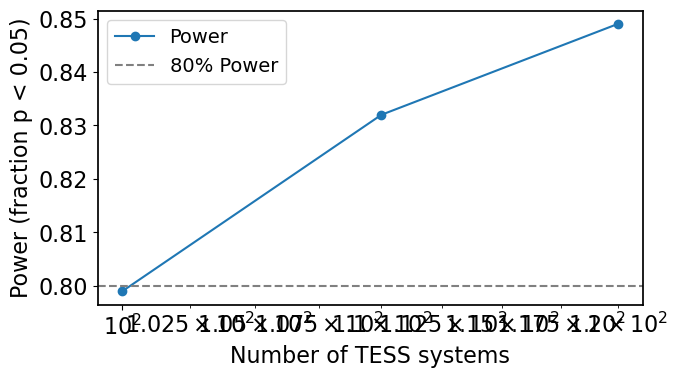

Sample sizes: [100, 110, 120]
Power: [0.799, 0.832, 0.849]


In [47]:

hot_sample = tess[tess['st_teff']>5500].copy()
cool_sample = tess[tess['st_teff']<3800].copy()

# create sims with subsample
sim_hot = SuppressionSimulator(
    planets_cat=hot_sample,
    sup_function=snow_sup,
    join_col="tid",
    prad_col="pl_rade",
    teff_col="st_teff",
    period_col='pl_orbper'        )

sim_cool = SuppressionSimulator(
    planets_cat=cool_sample,
    sup_function=snow_sup,
    join_col="tid",
    prad_col="pl_rade",
    teff_col="st_teff",
    period_col='pl_orbper'   )

# Define sample sizes
sample_sizes = [100, 110, 120]

# Run power analysis
power_results, _ = power_analysis(sim_hot, sim_cool, sample_sizes, 
                               n_subsamples=100, 
                               n_trials_per_sub=10)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, power_results, 'o-', label='Power')
ax.axhline(0.8, ls='--', color='gray', label='80% Power')
ax.set_xlabel('Number of TESS systems')
ax.set_ylabel('Power (fraction p < 0.05)')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('plots/power_analysis.png')
plt.show()

print("Sample sizes:", sample_sizes)
print("Power:", power_results)


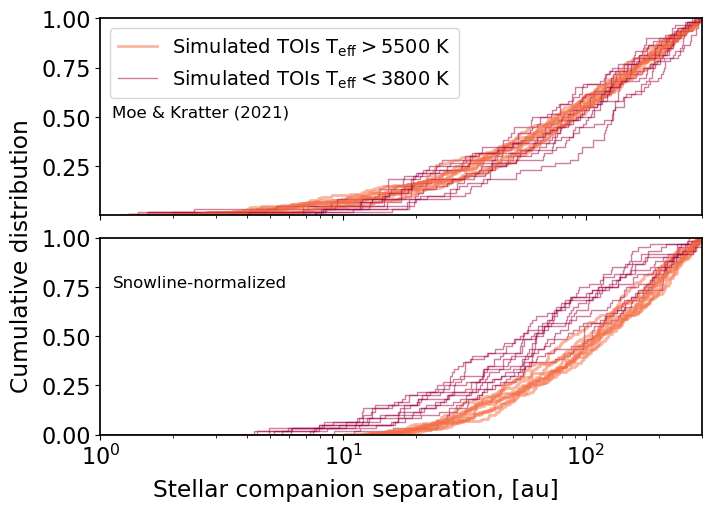

In [98]:

hot_sample = tess[tess['st_teff']>5500].copy()
#hot_sample = tess[tess['st_teff']>6200].copy()
cool_sample = tess[tess['st_teff']<3800].copy()

# create sims with subsample
sim_hot_snow = SuppressionSimulator(
    planets_cat=hot_sample,
    sup_function=snow_sup,
    join_col="tid",
    prad_col="pl_rade",
    teff_col="st_teff",
    period_col='pl_orbper'        )

sim_hot_mk = SuppressionSimulator(
    planets_cat=hot_sample,
    sup_function=mk_sup,
    join_col="tid",
    prad_col="pl_rade",
    teff_col="st_teff",
    period_col='pl_orbper'       )

sim_cool_snow = SuppressionSimulator(
    planets_cat=cool_sample,
    sup_function=snow_sup,
    join_col="tid",
    prad_col="pl_rade",
    teff_col="st_teff",
    period_col='pl_orbper'   )

sim_cool_mk = SuppressionSimulator(
    planets_cat=cool_sample,
    sup_function=mk_sup,
    join_col="tid",
    prad_col="pl_rade",
    teff_col="st_teff",
    period_col='pl_orbper'   )

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(7, 5), 
                        gridspec_kw={'hspace': 0},
                        layout="constrained")


axs[0].set_xscale('log')
axs[0].set_ylim(0.001,1)
axs[0].set_xlim(1,300)

for i in range(10):

    sim_hot_snow.run(max_a_draw=300.)
    sim_hot_mk.run(max_a_draw=300.)
    sim_cool_snow.run(max_a_draw=300.)
    sim_cool_mk.run(max_a_draw=300.)

    hot_result_snow = sim_hot_snow.get_results(suppression_style='planets')
    hot_result_mk = sim_hot_mk.get_results(suppression_style='planets')
    cool_result_snow = sim_cool_snow.get_results(suppression_style='planets')
    cool_result_mk = sim_cool_mk.get_results(suppression_style='planets')

    hot_subsample_snow = (hot_result_snow.survived_semimajor).sample(200, replace=True)
    hot_subsample_mk = (hot_result_mk.survived_semimajor).sample(200, replace=True)
    cool_subsample_snow = (cool_result_snow.survived_semimajor).sample(60, replace=True)
    cool_subsample_mk = (cool_result_mk.survived_semimajor).sample(60, replace=True)

    label_hot_mk = r'Simulated TOIs $T_\mathrm{eff}>5500$ K' if i == 0 else None
    label_cool_mk = r'Simulated TOIs $T_\mathrm{eff}<3800$ K' if i == 0 else None
    label_hot_snow = r'Simulated TOIs $T_\mathrm{eff}>5500$ K' if i == 0 else None
    label_cool_snow = r'Simulated TOIs $T_\mathrm{eff}<3800$ K' if i == 0 else None

    sns.ecdfplot(hot_subsample_mk, ax=axs[0], c='#f46d43',
                 lw=2, alpha=0.5, label=label_hot_mk)
    sns.ecdfplot(cool_subsample_mk, ax=axs[0], c='#9e0142',
                 lw=1, alpha=0.5, label=label_cool_mk)

    sns.ecdfplot(hot_subsample_snow, ax=axs[1], c='#f46d43',
                 lw=2, alpha=0.5,  label=label_hot_snow)
    sns.ecdfplot(cool_subsample_snow, ax=axs[1], c='#9e0142',
                 lw=1, alpha=0.5, label=label_cool_snow)

# add legends and remove per-subplot axis labels
axs[0].legend()
axs[0].text(0.02, 0.5, 'Moe & Kratter (2021)', 
            transform=axs[0].transAxes, fontsize=12, ha='left')
axs[1].text(0.02, 0.75, 'Snowline-normalized', 
            transform=axs[1].transAxes, fontsize=12, ha='left')

for ax in axs:
    ax.set(xlabel=None)  # should remove the axis label
    ax.set(ylabel=None)

fig.supxlabel('Stellar companion separation, [au]')
fig.supylabel('Cumulative distribution')

plt.savefig('plots/mk_vs_snow_ecdf.png')
plt.show()

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a

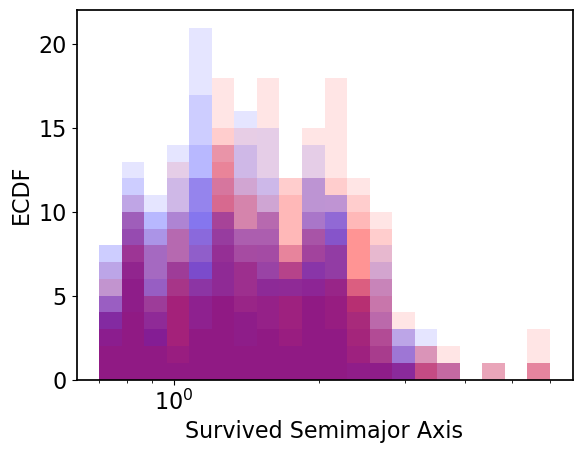

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a

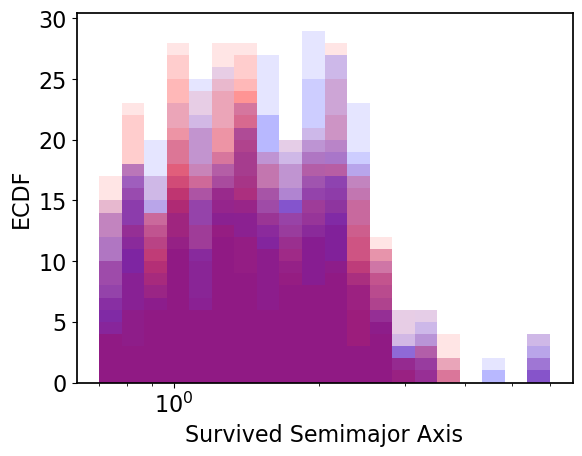

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7g

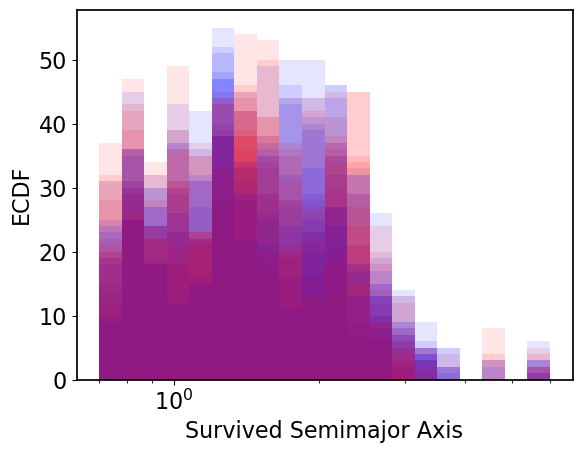

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a

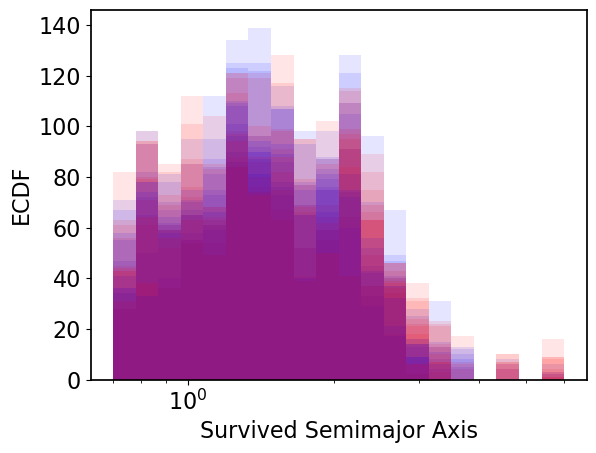

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res  = stats.anderson_ksamp([hot_subsample, cool_subsample])
/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_42117/2486673120.py:47: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable a

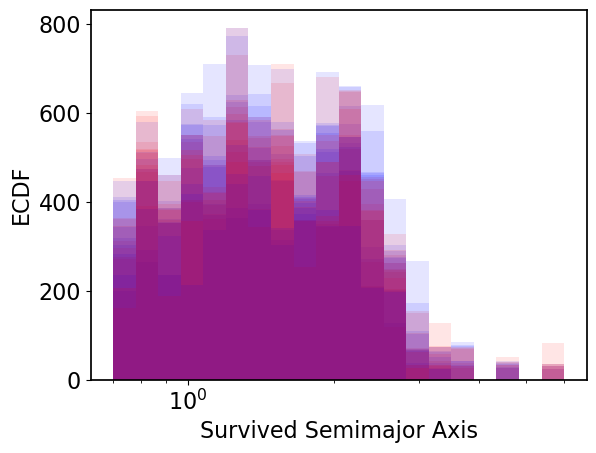

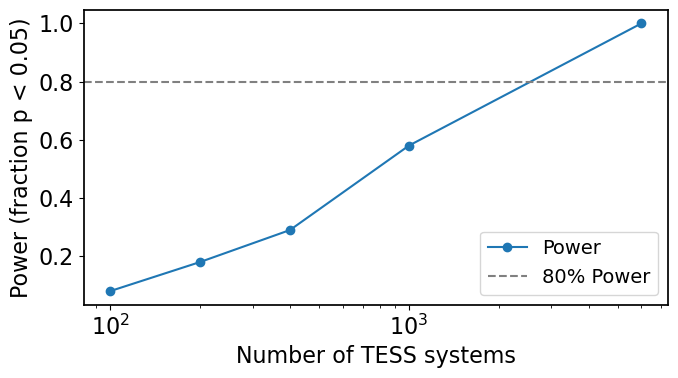

Sample sizes: [100, 200, 400, 1000, 6000]
Power: [0.08, 0.18, 0.29, 0.58, 1.0]


In [4]:

with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
          
# this will be the conjoined list of binaries
binaries = data["db_filtered"]
#binaries = binaries[(binaries['Teff1']>4000) & (binaries['Teff1']<6000)].copy()

# separation values (as lists) for each star in binary sample
tmp = binaries.groupby('KOI')['SepAU'].agg('unique')
binary_separations = np.concatenate(tmp.to_numpy())

# this will be the KOIs that are presumed single
limit = data["kois_filtered_cc"]["koi_prad_err1"]<0.25
limit = limit & (data['kois_filtered_cc']["koi_prad"]<6)
limit = limit & (data['kois_filtered_cc']["koi_prad"]>0.7)
singles = data["kois_filtered_cc"].loc[limit]

# create sims with subsample
sim_snow = SuppressionSimulator(
    planets_cat=singles,
    sup_function=snow_sup,
    join_col="KOI",
    prad_col="koi_prad",
    teff_col="koi_steff",
    random_state=42,             
)

sim_mk = SuppressionSimulator(
    planets_cat=singles,
    sup_function=mk_sup,
    join_col="KOI",
    prad_col="koi_prad",
    teff_col="koi_steff",
    random_state=42,             
)

# Define sample sizes
sample_sizes = [100, 200, 400, 1000, 6000]

# Run power analysis
_, power_results = power_analysis(sim_snow, sim_mk, sample_sizes, 
                               n_subsamples=10, 
                               n_trials_per_sub=10)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, power_results, 'o-', label='Power')
ax.axhline(0.8, ls='--', color='gray', label='80% Power')
ax.set_xlabel('Number of TESS systems')
ax.set_ylabel('Power (fraction p < 0.05)')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('plots/power_analysis.png')
plt.show()

print("Sample sizes:", sample_sizes)
print("Power:", power_results)

In [47]:
scipy.__version__

'1.17.1'